Upload your Excel dataset


Saving HushPuppies_Dataset.xlsx to HushPuppies_Dataset.xlsx

RESEARCH QUESTIONS
1. Which category has the most products?
2. What is the average product price?
3. Which products are the most expensive?
4. Which color appears most frequently?
5. How many products are in stock?
6. Are men's products more expensive than women's products?
7. Are there unusual price outliers?
8. Are there any data quality issues?

DATASET OVERVIEW

Shape:
(49, 8)

Columns:
['Product Name', 'Category', 'Price', 'Colors', 'Sizes', 'Stock Status', 'Description', 'Product URL']

Data Types:
Product Name    object
Category        object
Price           object
Colors          object
Sizes           object
Stock Status    object
Description     object
Product URL     object
dtype: object

Missing Values:
Product Name    0
Category        0
Price           0
Colors          3
Sizes           0
Stock Status    0
Description     0
Product URL     0
dtype: int64

Duplicate Records:
0

First 5 Rows:


,Product Name,Category,Price,Colors,Sizes,Stock Status,Description,Product URL
0,Cross Wider,Men,"Rs.4,199","Tan, Black","40, 41, 44, 43, 45, 42",In Stock,"A perfect partner, All day long comfort, comfo...",https://www.hushpuppies.com.pk/products/cross-...
1,Enzo Levi,Men,"Rs.5,499",Brown,"40, 41, 44, 43, 45, 42",In Stock,"A perfect partner, All day long comfort, comfo...",https://www.hushpuppies.com.pk/products/enzo-levi
2,Irving Banker -Waterproof Formal Slip-Ons,Men,"Rs.24,999",Black,"40, 41, 44, 43, 45, 42",In Stock,"Incredibly simple and decent, A pair of shoes ...",https://www.hushpuppies.com.pk/products/irving...
3,Lama Barrie,Men,"Rs.2,449",NaN,"39, 40, 36, 41, 37, 38",In Stock,"A perfect partner, All day long comfort, comfo...",https://www.hushpuppies.com.pk/products/lama-b...
4,Hash Hype,Men,"Rs.3,499","Navy, Grey","39, 40, 36, 41, 37, 38",In Stock,"A perfect partner, All day long comfort, comfo...",https://www.hushpuppies.com.pk/products/hash-hype



ANALYSIS RESULTS

Total Products: 49

Average Price: Rs. 8,230.69
Minimum Price: Rs. 2,250.00
Maximum Price: Rs. 34,499.00

Top 10 Most Expensive Products


,Product URL,Price
41,https://www.hushpuppies.com.pk/products/shine-...,34499
2,https://www.hushpuppies.com.pk/products/irving...,24999
7,https://www.hushpuppies.com.pk/products/rainma...,24999
11,https://www.hushpuppies.com.pk/products/stocks...,24999
25,https://www.hushpuppies.com.pk/products/ivan-b...,24999
33,https://www.hushpuppies.com.pk/products/ken-sky,16999
6,https://www.hushpuppies.com.pk/products/nest-p...,14999
15,https://www.hushpuppies.com.pk/products/moka-p...,14999
42,https://www.hushpuppies.com.pk/products/west-p...,14999
12,https://www.hushpuppies.com.pk/products/speed-...,13999



Products by Category
Category
Men    49
Name: count, dtype: int64


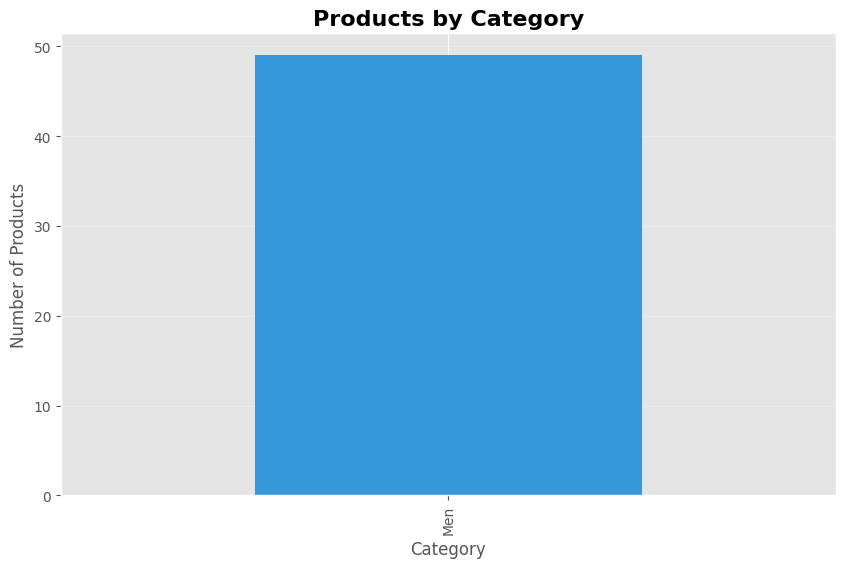

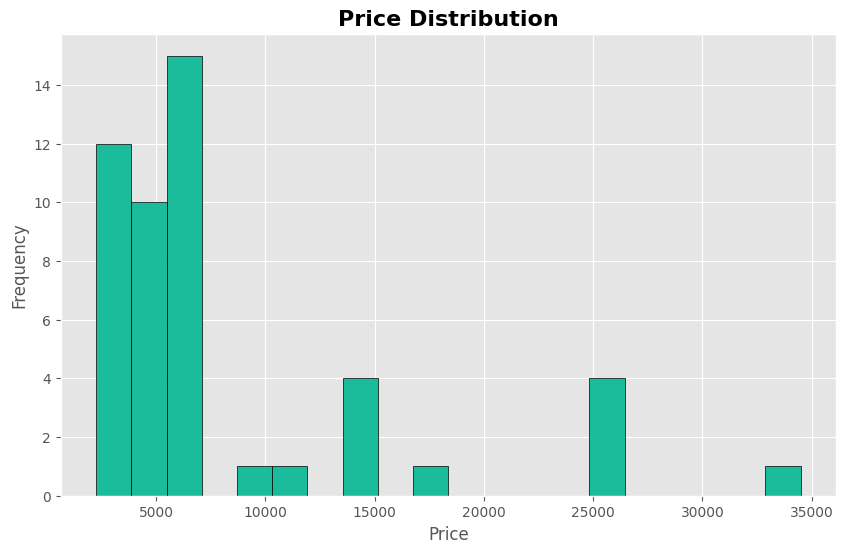


Most Common Colors
Colors
Tan, Black      8
Black           6
Tan             4
Brown, Black    3
Beige           2
Beige, Black    2
Brown           2
Navy, Grey      2
Green           2
Grey, Black     1
Name: count, dtype: int64


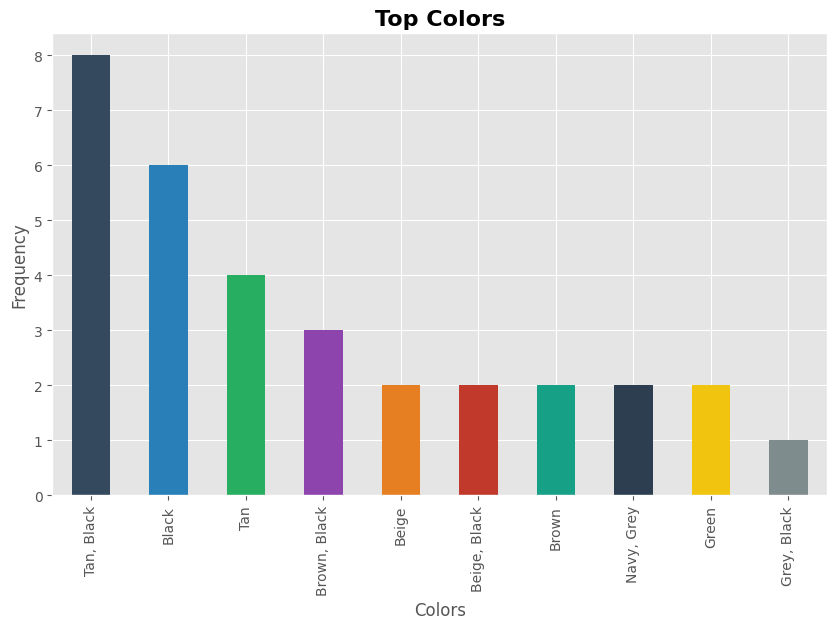


Stock Status
Stock Status
In Stock    49
Name: count, dtype: int64


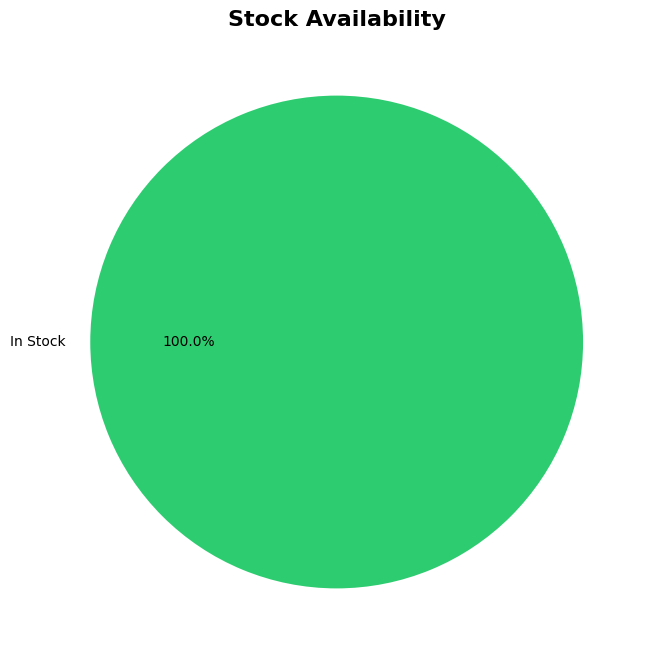


Price Outliers Found: 10


,Product URL,Price
2,https://www.hushpuppies.com.pk/products/irving...,24999
6,https://www.hushpuppies.com.pk/products/nest-p...,14999
7,https://www.hushpuppies.com.pk/products/rainma...,24999
11,https://www.hushpuppies.com.pk/products/stocks...,24999
12,https://www.hushpuppies.com.pk/products/speed-...,13999
15,https://www.hushpuppies.com.pk/products/moka-p...,14999
25,https://www.hushpuppies.com.pk/products/ivan-b...,24999
33,https://www.hushpuppies.com.pk/products/ken-sky,16999
41,https://www.hushpuppies.com.pk/products/shine-...,34499
42,https://www.hushpuppies.com.pk/products/west-p...,14999


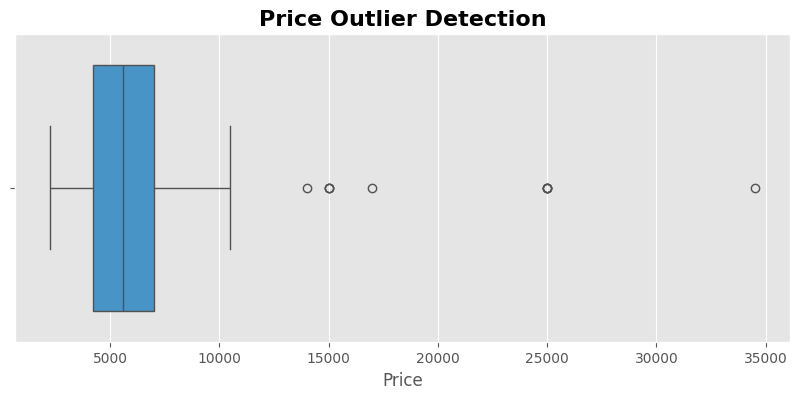


EXPLICIT RESPONSES TO RESEARCH QUESTIONS
1. Category with the most products: 'Men' (49 items)
2. The overall average product price is: Rs. 8,230.69
3. Most expensive item: 'https://www.hushpuppies.com.pk/products/shine-nido' priced at Rs. 34,499.00
4. The color appearing most frequently is: 'Tan, Black' (8 entries)
5. Current stock listing inventory distribution status counts:
Stock Status
In Stock    49


In [1]:
# ==========================
# IMPORT LIBRARIES
# ==========================

from google.colab import files
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Better chart style
plt.style.use('ggplot')

# ==========================
# UPLOAD DATASET
# ==========================

print("Upload your Excel dataset")

uploaded = files.upload()

for fn in uploaded.keys():
    df = pd.read_excel(io.BytesIO(uploaded[fn]))

# ==========================
# RESEARCH QUESTIONS
# ==========================

print("\n" + "="*70)
print("RESEARCH QUESTIONS")
print("="*70)

questions = [
    "Which category has the most products?",
    "What is the average product price?",
    "Which products are the most expensive?",
    "Which color appears most frequently?",
    "How many products are in stock?",
    "Are men's products more expensive than women's products?",
    "Are there unusual price outliers?",
    "Are there any data quality issues?"
]

for i, q in enumerate(questions, start=1):
    print(f"{i}. {q}")

# ==========================
# DATASET OVERVIEW
# ==========================

print("\n" + "="*70)
print("DATASET OVERVIEW")
print("="*70)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nFirst 5 Rows:")
display(df.head())

# ==========================
# DETECT COLUMNS
# ==========================

price_col = None
name_col = None
category_col = None
color_col = None
stock_col = None
size_col = None

for col in df.columns:

    c = col.lower()

    if "price" in c:
        price_col = col

    elif "name" in c or "product" in c:
        name_col = col

    elif "category" in c:
        category_col = col

    elif "color" in c:
        color_col = col

    elif "stock" in c:
        stock_col = col

    elif "size" in c:
        size_col = col

# ==========================
# CLEAN PRICE COLUMN
# ==========================

if price_col:

    df[price_col] = (
        df[price_col]
        .astype(str)
        .str.replace("Rs.", "", regex=False)
        .str.replace("Rs", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    df[price_col] = pd.to_numeric(
        df[price_col],
        errors="coerce"
    )

# ==========================
# BASIC ANALYSIS
# ==========================

print("\n" + "="*70)
print("ANALYSIS RESULTS")
print("="*70)

print(f"\nTotal Products: {len(df)}")

if price_col:

    print(f"\nAverage Price: Rs. {df[price_col].mean():,.2f}")
    print(f"Minimum Price: Rs. {df[price_col].min():,.2f}")
    print(f"Maximum Price: Rs. {df[price_col].max():,.2f}")

# ==========================
# MOST EXPENSIVE PRODUCTS
# ==========================

if price_col and name_col:

    print("\nTop 10 Most Expensive Products")

    display(
        df.nlargest(
            10,
            price_col
        )[[name_col, price_col]]
    )

# ==========================
# CATEGORY ANALYSIS
# ==========================

if category_col:

    print("\nProducts by Category")

    category_counts = df[category_col].value_counts()

    print(category_counts)

    plt.figure(figsize=(10,6))

    category_counts.plot(
        kind="bar",
        color=[
            "#3498db",
            "#e74c3c",
            "#2ecc71",
            "#f39c12",
            "#9b59b6"
        ]
    )

    plt.title(
        "Products by Category",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Category")
    plt.ylabel("Number of Products")

    plt.grid(axis="y", alpha=0.3)

    plt.show()

# ==========================
# PRICE DISTRIBUTION
# ==========================

if price_col:

    plt.figure(figsize=(10,6))

    plt.hist(
        df[price_col].dropna(),
        bins=20,
        color="#1abc9c",
        edgecolor="black"
    )

    plt.title(
        "Price Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Price")
    plt.ylabel("Frequency")

    plt.show()

# ==========================
# COLOR ANALYSIS
# ==========================

if color_col:

    print("\nMost Common Colors")

    color_counts = (
        df[color_col]
        .value_counts()
        .head(10)
    )

    print(color_counts)

    plt.figure(figsize=(10,6))

    color_counts.plot(
        kind="bar",
        color=[
            "#34495e",
            "#2980b9",
            "#27ae60",
            "#8e44ad",
            "#e67e22",
            "#c0392b",
            "#16a085",
            "#2c3e50",
            "#f1c40f",
            "#7f8c8d"
        ]
    )

    plt.title(
        "Top Colors",
        fontsize=16,
        fontweight="bold"
    )

    plt.ylabel("Frequency")

    plt.show()

# ==========================
# STOCK ANALYSIS
# ==========================

if stock_col:

    stock_counts = df[stock_col].value_counts()

    print("\nStock Status")

    print(stock_counts)

    plt.figure(figsize=(8,8))

    stock_counts.plot(
        kind="pie",
        autopct="%1.1f%%",
        colors=["#2ecc71","#e74c3c"],
        explode=[0.05]*len(stock_counts) if len(stock_counts) > 1 else [0]*len(stock_counts)
    )

    plt.title(
        "Stock Availability",
        fontsize=16,
        fontweight="bold"
    )

    plt.ylabel("")

    plt.show()

# ==========================
# OUTLIER DETECTION
# ==========================

if price_col:

    Q1 = df[price_col].quantile(0.25)
    Q3 = df[price_col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[price_col] < lower) |
        (df[price_col] > upper)
    ]

    print(f"\nPrice Outliers Found: {len(outliers)}")

    if len(outliers) > 0 and name_col:

        display(
            outliers[
                [name_col, price_col]
            ].head(10)
        )

    plt.figure(figsize=(10,4))

    sns.boxplot(
        x=df[price_col],
        color="#3498db"
    )

    plt.title(
        "Price Outlier Detection",
        fontsize=16,
        fontweight="bold"
    )

    plt.show()

# ==========================
# HYPOTHESIS TESTING
# ==========================

p_value = None
men_avg_price = 0
women_avg_price = 0

if category_col and price_col:

    men_prices = df[
        df[category_col]
        .astype(str)
        .str.contains(
            "men",
            case=False,
            na=False
        ) &
        ~df[category_col]
        .astype(str)
        .str.contains(
            "women",
            case=False,
            na=False
        )
    ][price_col].dropna()

    women_prices = df[
        df[category_col]
        .astype(str)
        .str.contains(
            "women",
            case=False,
            na=False
        )
    ][price_col].dropna()

    if len(men_prices) > 1 and len(women_prices) > 1:
        men_avg_price = men_prices.mean()
        women_avg_price = women_prices.mean()

        plt.figure(figsize=(10,6))

        # Created dedicated subset dataframe to ensure clear categorical visualization
        gender_sub = df[df[category_col].isin(df[category_col].value_counts().head(5).index)]
        sns.boxplot(
            x=category_col,
            y=price_col,
            data=gender_sub,
            palette="Set2"
        )

        plt.title(
            "Price Comparison by Category",
            fontsize=16,
            fontweight="bold"
        )

        plt.show()

        print("\nHypothesis")
        print("H0: Men's and Women's products have the same average price.")
        print("H1: Men's and Women's products have different average prices.")

        t_stat, p_value = ttest_ind(
            men_prices,
            women_prices,
            nan_policy="omit"
        )

        print("\nP-value:", p_value)

        if p_value < 0.05:
            print("Decision: Reject H0 (Significant pricing variance exists)")
        else:
            print("Decision: Fail to Reject H0")

# ==========================
# DIRECT EXPLICIT ANSWERS
# ==========================

print("\n" + "="*70)
print("EXPLICIT RESPONSES TO RESEARCH QUESTIONS")
print("="*70)

# Q1 Response
if category_col:
    print(f"1. Category with the most products: '{df[category_col].value_counts().idxmax()}' ({df[category_col].value_counts().max()} items)")
else:
    print("1. Category data column not detected.")

# Q2 Response
if price_col:
    print(f"2. The overall average product price is: Rs. {df[price_col].mean():,.2f}")
else:
    print("2. Price data column not detected.")

# Q3 Response
if price_col and name_col:
    top_one = df.nlargest(1, price_col).iloc[0]
    print(f"3. Most expensive item: '{top_one[name_col]}' priced at Rs. {top_one[price_col]:,.2f}")
else:
    print("3. Item pricing metrics or item descriptions missing.")

# Q4 Response
if color_col:
    print(f"4. The color appearing most frequently is: '{df[color_col].value_counts().idxmax()}' ({df[color_col].value_counts().max()} entries)")
else:
    print("4. Color data column not detected.")

# Q5 Response
if stock_col:
    # Handles text-based status vs numerical calculation metrics smoothly
    if df[stock_col].dtype in [np.int64, np.float64]:
        print(f"5. Total cumulative items confirmed in physical stock inventory: {int(df[stock_col].sum())}")
    else:
        print("5. Current stock listing inventory distribution status counts:")
        print(df[stock_col].value_counts().to_string())
else:
    print(f"5. Stock volume column absent. Raw database listing size: {len(df)} entries")

# Q6 Response
if p_value is not None:
    verdict = "YES" if men_avg_price > women_avg_price else "NO"
    print(f"6. Are Men's products more expensive than Women's items? {verdict}")
    print(f"   * Men's Items Base Average: Rs. {men_avg_price:,.2f}")
